# 01 - Exploration du dataset Freshness44

Ce notebook sert à comprendre la structure du dataset avant l'entraînement.

Objectifs :

- compter les images par `product_type` et par `freshness` ;
- comparer les images `fresh` et `rotten` pour chaque produit ;
- afficher quelques exemples d'images.

## Chargement de la configuration

In [60]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display
from PIL import Image, UnidentifiedImageError

In [61]:
current_path = Path.cwd()
project_root = current_path if (current_path / "config.yaml").exists() else current_path.parent
config_path = project_root / "config.yaml"

if not config_path.exists():
    raise FileNotFoundError(
        "config.yaml est introuvable. Lancez le notebook depuis la racine du projet ou depuis notebooks/."
    )

with config_path.open("r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

dataset_path = project_root / config["paths"]["raw_data_dir"]
figures_path = project_root / config["paths"]["figures_dir"]
figures_path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Dataset path: {dataset_path}")
print(f"Figures path: {figures_path}")

if not dataset_path.exists():
    print("Le dossier du dataset est introuvable. Vérifiez paths.raw_data_dir dans config.yaml.")

Project root: c:\Users\antoc\FreshOrRotten
Dataset path: c:\Users\antoc\FreshOrRotten\data\raw
Figures path: c:\Users\antoc\FreshOrRotten\reports\figures


## Parcours du dataset

La fonction suivante parcourt les dossiers et construit un index simple des images.
Elle garde seulement les chemins, le `product_type` et la `freshness`.

In [62]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
ignored_product_folders = {
    "train",
    "test",
    "validation",
    "valid",
    "val",
    "image",
    "images",
    "raw",
    "dataset",
    "fresh",
    "rotten",
    "unknown",
}


def normalize_name(name):
    """Retourne un nom simple pour comparer les dossiers du dataset."""
    return name.lower().strip().replace("-", "_").replace(" ", "_")


def clean_product_type(folder_name):
    """Retire les mots liés à la fraîcheur pour isoler le type du produit."""
    cleaned_name = normalize_name(folder_name)
    cleaned_name = re.sub(r"fresh|rotten", "", cleaned_name)
    cleaned_name = cleaned_name.replace("_", " ")
    cleaned_name = " ".join(cleaned_name.split())
    return cleaned_name if cleaned_name else "unknown"


def detect_freshness(path_parts):
    """Détecte fresh ou rotten à partir des noms de dossiers."""
    normalized_parts = [normalize_name(part) for part in path_parts]

    for part in normalized_parts:
        if "rotten" in part:
            return "rotten"

    for part in normalized_parts:
        if "fresh" in part:
            return "fresh"

    return "unknown"


def detect_product_type(relative_path):
    """Déduit le type du produit à partir du dossier le plus précis."""
    folder_parts = relative_path.parts[:-1]

    # Le dataset peut mélanger la fraîcheur et le produit dans le même nom de dossier.
    for folder_name in reversed(folder_parts):
        product_type = clean_product_type(folder_name)
        if product_type not in ignored_product_folders:
            return product_type

    return "unknown"


def scan_dataset(dataset_path):
    """Parcourt le dataset et retourne un tableau avec les métadonnées des images."""
    columns = ["image_path", "product_type", "freshness"]

    if not dataset_path.exists():
        return pd.DataFrame(columns=columns)

    records = []

    for image_path in dataset_path.rglob("*"):
        if not image_path.is_file():
            continue

        if image_path.suffix.lower() not in image_extensions:
            continue

        relative_path = image_path.relative_to(dataset_path)

        # On garde seulement les chemins pour éviter de charger toutes les images en mémoire.
        records.append(
            {
                "image_path": image_path,
                "product_type": detect_product_type(relative_path),
                "freshness": detect_freshness(relative_path.parts),
            }
        )

    return pd.DataFrame(records, columns=columns)

In [63]:
image_index_df = scan_dataset(dataset_path)

print(f"Nombre d'images trouvées : {len(image_index_df)}")
display(image_index_df.head())

if not image_index_df.empty and (image_index_df["freshness"] == "unknown").any():
    unknown_count = (image_index_df["freshness"] == "unknown").sum()
    print(f"Attention : {unknown_count} image(s) ont une freshness inconnue.")

Nombre d'images trouvées : 53616


,image_path,product_type,freshness
0,c:\Users\antoc\FreshOrRotten\data\raw\Apple_Fr...,apple,fresh
1,c:\Users\antoc\FreshOrRotten\data\raw\Apple_Fr...,apple,fresh
2,c:\Users\antoc\FreshOrRotten\data\raw\Apple_Fr...,apple,fresh
3,c:\Users\antoc\FreshOrRotten\data\raw\Apple_Fr...,apple,fresh
4,c:\Users\antoc\FreshOrRotten\data\raw\Apple_Fr...,apple,fresh


## Tableau de synthèse

`image_count` correspond au nombre d'images pour chaque couple `product_type` / `freshness`.

In [64]:
if image_index_df.empty:
    print("Aucune image trouvée. Vérifiez le chemin du dataset.")
else:
    summary_df = (
        image_index_df.groupby(["product_type", "freshness"])
        .size()
        .reset_index(name="image_count")
        .sort_values(["product_type", "freshness"])
    )

    display(summary_df)

,product_type,freshness,image_count
0,apple,fresh,3468
1,apple,rotten,4263
2,banana,fresh,3513
3,banana,rotten,3605
4,bellpepper,fresh,1634
5,bellpepper,rotten,2108
6,bitter gourd,fresh,327
7,bitter gourd,rotten,357
8,carrot,fresh,605
9,carrot,rotten,507


## Nombre d'images par classe fresh/rotten

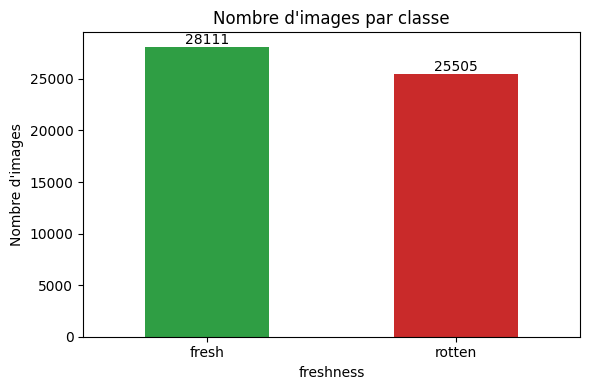

In [65]:
if image_index_df.empty:
    print("Aucune image à afficher.")
else:
    class_counts = (
        image_index_df.groupby("freshness")
        .size()
        .reindex(["fresh", "rotten", "unknown"], fill_value=0)
    )
    class_counts = class_counts[class_counts > 0]
    class_colors = {"fresh": "#2f9e44", "rotten": "#c92a2a", "unknown": "#868e96"}

    ax = class_counts.plot(
        kind="bar",
        color=[class_colors.get(label, "#495057") for label in class_counts.index],
        figsize=(6, 4),
    )
    ax.set_title("Nombre d'images par classe")
    ax.set_xlabel("freshness")
    ax.set_ylabel("Nombre d'images")
    ax.bar_label(ax.containers[0])
    plt.xticks(rotation=0)
    plt.tight_layout()
    figure = ax.get_figure()
    figure.savefig(figures_path / "image_count_by_freshness.png", dpi=150, bbox_inches="tight")
    plt.show()

Cette figure montre un léger déséquilibre entre fresh et rotten. Cependant, l'écart n'est que de 3000 images et chaque classe a + de 25 000 images. 

La dataset est donc considéré comme équilibré pour chaque classe.  


## Nombre d'images par product_type

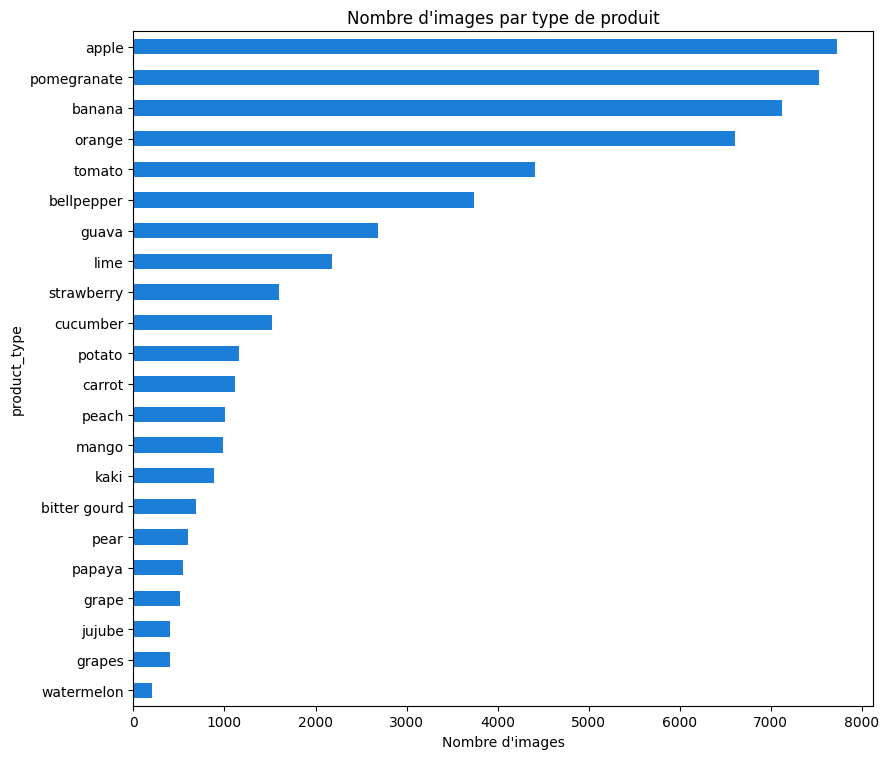

In [66]:
if image_index_df.empty:
    print("Aucune image à afficher.")
else:
    product_counts = image_index_df.groupby("product_type").size().sort_values()
    figure_height = min(14, max(4, 0.35 * len(product_counts)))

    ax = product_counts.plot(kind="barh", figsize=(9, figure_height), color="#1c7ed6")
    ax.set_title("Nombre d'images par type de produit")
    ax.set_xlabel("Nombre d'images")
    ax.set_ylabel("product_type")
    plt.tight_layout()
    figure = ax.get_figure()
    figure.savefig(figures_path / "image_count_by_product_type.png", dpi=150, bbox_inches="tight")
    plt.show()

On observe ici un véritable déséquilibre entre produit. 

Le modèle aura peut-etre plus du mal avec certaines classes moins representées ? 

## Nombre d'images fresh/rotten par product_type


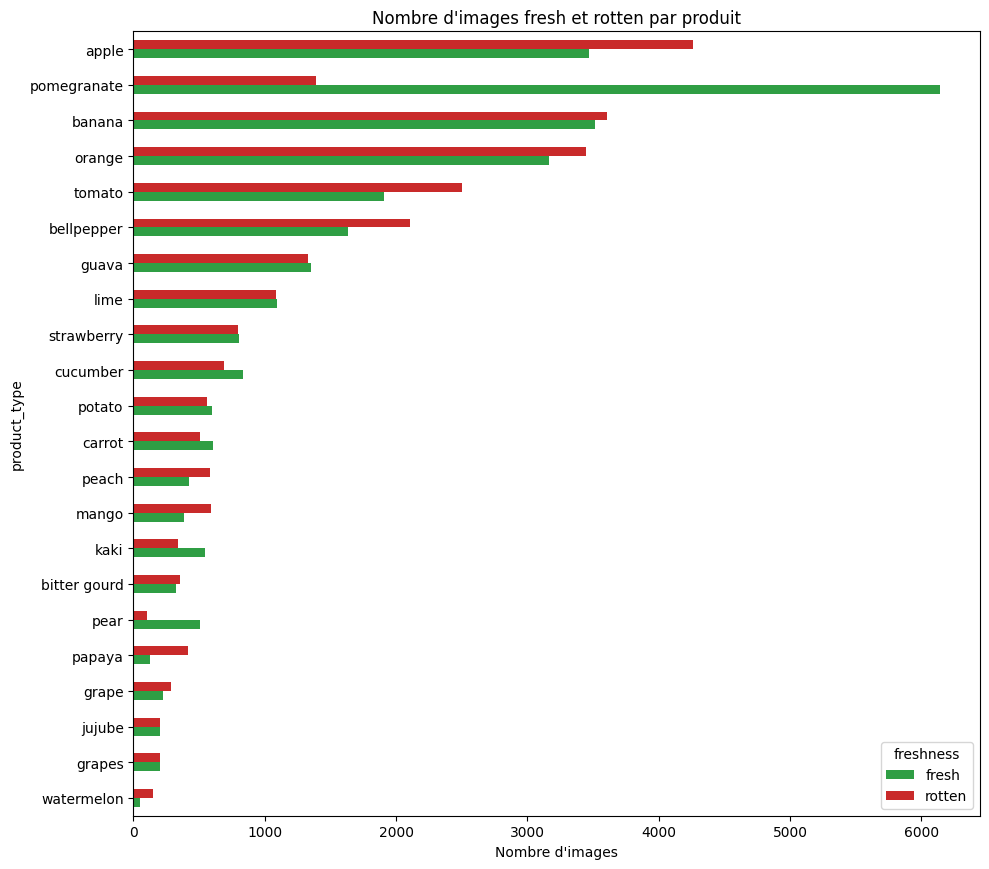

In [67]:
if image_index_df.empty:
    print("Aucune image à afficher.")
else:
    product_freshness_counts = (
        image_index_df[image_index_df["freshness"].isin(["fresh", "rotten"])]
        .groupby(["product_type", "freshness"])
        .size()
    )
    product_freshness_counts = (
        product_freshness_counts
        .unstack(fill_value=0)
        .reindex(columns=["fresh", "rotten"], fill_value=0)
    )

    if product_freshness_counts.empty:
        print("Aucune image fresh ou rotten à afficher.")
    else:
        product_freshness_counts["total"] = product_freshness_counts.sum(axis=1)
        product_freshness_counts = product_freshness_counts.sort_values("total").drop(columns="total")
        figure_height = min(16, max(5, 0.4 * len(product_freshness_counts)))
    ax = product_freshness_counts.plot(
        kind="barh",
        figsize=(10, figure_height),
        color=["#2f9e44", "#c92a2a"],
        )
    ax.set_title("Nombre d'images fresh et rotten par produit")
    ax.set_xlabel("Nombre d'images")
    ax.set_ylabel("product_type")
    ax.legend(title="freshness")
    plt.tight_layout()
    figure = ax.get_figure()
    figure.savefig(figures_path / "image_count_by_product_type_and_freshness.png", dpi=150, bbox_inches="tight")
    plt.show()

La figure montre que les produits non pas un nombre identique d'images classé Fresh et Rotten.

## Exemples d'images

Les cellules suivantes chargent seulement quelques images pour vérifier visuellement le dataset.

In [68]:
def show_example_images(image_index_df, freshness, max_images=6):
    """Affiche quelques images pour une classe donnée."""
    if image_index_df.empty:
        print("Aucune image disponible.")
        return

    selected_df = image_index_df[image_index_df["freshness"] == freshness]

    if selected_df.empty:
        print(f"Aucune image trouvée pour la classe {freshness}.")
        return

    selected_df = selected_df.sample(
        n=min(max_images, len(selected_df)),
        random_state=config["training"]["random_seed"],
    )

    figure, axes = plt.subplots(1, len(selected_df), figsize=(3 * len(selected_df), 3))

    if len(selected_df) == 1:
        axes = [axes]

    # Les pixels sont chargés uniquement pour les exemples affichés.
    for axis, row in zip(axes, selected_df.itertuples(index=False)):
        try:
            with Image.open(row.image_path) as image:
                axis.imshow(image.copy())
        except (OSError, UnidentifiedImageError):
            axis.text(0.5, 0.5, "Image invalide", ha="center", va="center")

        axis.set_title(row.product_type)
        axis.axis("off")

    figure.suptitle(f"Exemples {freshness}", y=1.05)
    plt.tight_layout()
    plt.show()

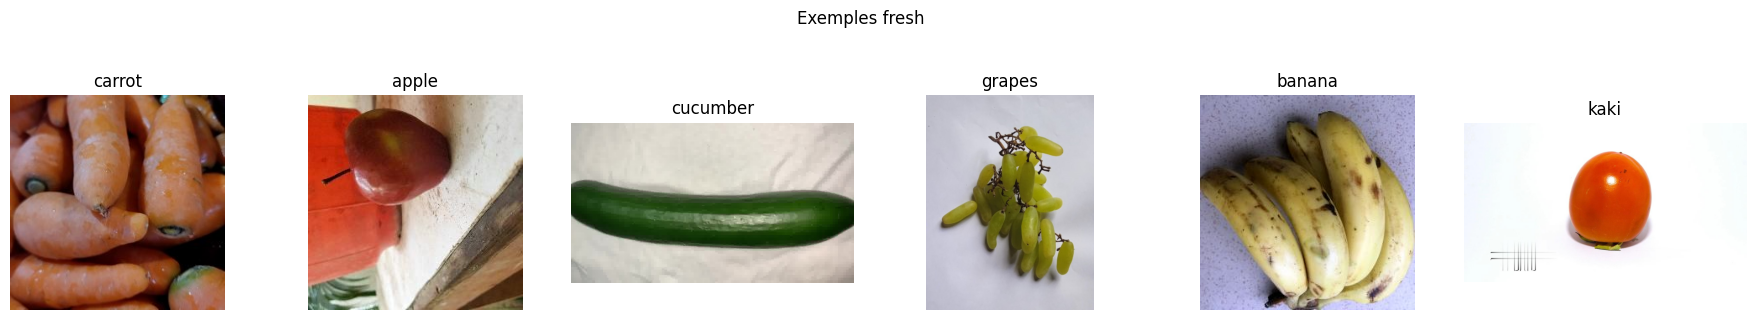

In [69]:
show_example_images(image_index_df, "fresh")

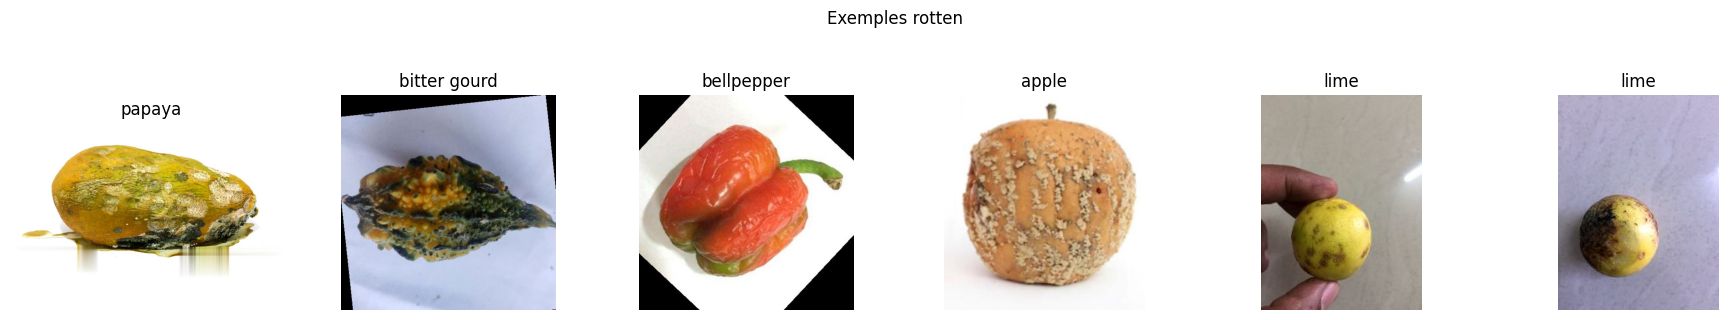

In [70]:
show_example_images(image_index_df, "rotten")

## Conclusion

Après exécution du notebook, les points à surveiller sont :

- un possible déséquilibre entre les classes `fresh` et `rotten` ;
- les `product_type` avec peu d'images, qui peuvent rendre l'évaluation instable ;
- l'intérêt du `unseen_category_split` pour tester des catégories jamais vues pendant l'entraînement.

Ces observations guideront la création des splits et l'interprétation des résultats.